# Instructions
To use this notebook, complete the following four steps:

### 1. Set your Python environment
This notebook requires a python environment with scipy, matplotlib, numpy, skimage, and pandas.  If you are working in VS Code, make sure to set your environment in the upper right corner of the screen before running the notebook. See [README](README) for one time installation instructions if you do not have an environment set up.

### 2. Set the parameters
See "Set Parameters" section below. The parameters that change every time are `mainFolder` and `idlFile`. Ideally the remaing parameters will remain constant across your experiments. See [README](README) for more information on the parameters.

### 3. Run the notebook 
You can run each cell of the notebook individually or run all at once. In VS Code, "Run All" is a button at the top of the screen. It is often useful to start by choosing "Run All."

### 4. Review the results!
This notebook makes two figures. Use these figures to confirm your parameters! If the figures don't make sense, your downstream analysis won't either!!

The bead identification figure shows each detected bead as a yellow star. If there are too few (many) stars, the `relThresh` parameter might be too high (low). Too few stars will leave beads in the data and slow down processing; too many stars will unncessarily remove real data.

The localization removal figure shows the localizations that remain after bead removal. Holes in the data should line up with the underlying beads image. Beads often show up elongated in y on the iPALM, which is why `rRemoveY` is usually greater than `rRemoveX`. Increase or decrease these parameters to remove more or less data around each bead. If the radius becomes too small, spurious bead localizations will remain in the data.

# Set Parameters

In [1]:
# Set your parameters before running the script.
# Start by setting the folder and the name of the IDL file.
# Change the other parameter as necessary based on the figures/results.

## Data Location
# Make sure to use / instead of \ in path names

# mainFolder = "E:/2026-09-29_iPALM_beadRemoval_Python/ExampleDatasets/26.04.13-1"  
# idlFile = "XYZ_Run1-560_c123_sum_merge_IDL"

mainFolder = "E:/2026-09-29_iPALM_beadRemoval_Python/ExampleDatasets/26.04.17"
idlFile = "Run1-560_c123_sum_X18_merged_IDL"

## Bead Identification Parameters
noiseSize = 1 # pixels for smoothing
beadSize = 3 # approximate radius of a bead in the total raw data image (pixels)
relThresh = 0.025 # thresholding on the bead image

## Bead Removal Parameters
rRemoveX = 3 # Number of pixels to remove around each bead in X
rRemoveY = 5 # Number of pixels to remove around each bead in Y

## Save
saveName = mainFolder + "/" + idlFile + "_beadsRemoved.txt"

# Run the Removal

In [2]:
## Import packages
from scipy.io import readsav
import matplotlib.pyplot as plt
import numpy as np
from skimage.filters import difference_of_gaussians
from skimage.feature import peak_local_max
import pandas as pd
from datetime import datetime
tstart = datetime.now()

In [3]:
# Read the SAV file and extract relevant data
data = readsav(mainFolder + "/" + idlFile + ".sav")

total = data['totalrawdata']

headers = data['rownames']
headers = np.array(headers,dtype=str)

ascii = data['cgroupparams']

del data # Save memory

c:\Users\leer\.conda\envs\beadRemoval\Lib\site-packages\scipy\io\_idl.py:338: UserWarning: Using experimental 64-bit array read
  rectypedesc = _read_typedesc(f)


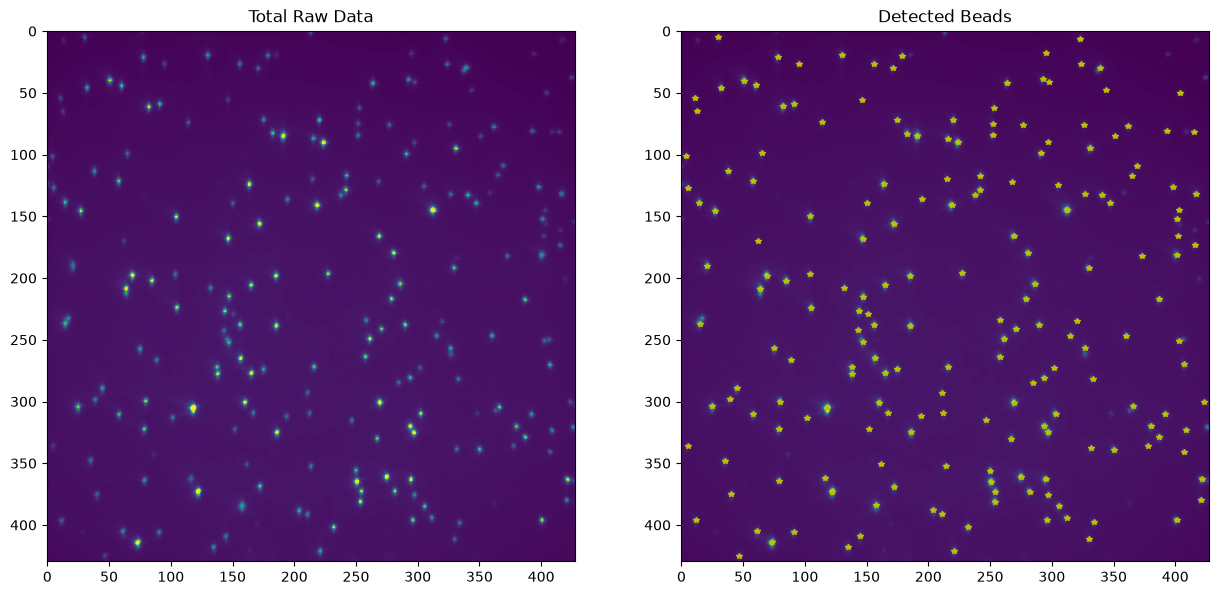

In [ ]:
# Identify beads
[per01,per99] = np.percentile(total,[0.1,99.9]) # This saturates the image a little bit to make it easier to look at the plots.

b = difference_of_gaussians(total,low_sigma=noiseSize,high_sigma=beadSize)
pk = peak_local_max(b,min_distance=beadSize,threshold_rel=relThresh)

# Plot the results
fig, axs = plt.subplots(1,2)
fig.set_figwidth(15)
fig.set_figheight(8)

axs[0].imshow(total,aspect='equal',vmin=per01,vmax=per99)
# axs[0].axis('off')
axs[0].set_title('Total Raw Data')

axs[1].imshow(total,aspect='equal',vmin=per01,vmax=per99)
# axs[1].axis('off')
axs[1].set_title('Detected Beads')
axs[1].plot(pk[:,1],pk[:,0],'y*',markersize=beadSize+1)

plt.show()

## **Warning**: If the beads are not detected correctly above, the following steps will not be valid!

In [ ]:
# Remove the beads from the localization data
print(ascii.shape)

x = np.ascontiguousarray(ascii[:,2])
y = np.ascontiguousarray(ascii[:,3])
toRemove = np.isinf(x)

for kk in np.arange(0,len(pk)):

    x1 = pk[kk,1]
    y1 = pk[kk,0]   

    dx = x-x1
    dy = y-y1

    currentBead = (np.divide(dx**2,rRemoveX**2)+np.divide(dy**2,rRemoveY**2) < 1); # equation for an ellipse with width 2a & height 2b: x^2/a^2 + y^2/b^2 = 1
    toRemove = np.logical_or(toRemove,currentBead)

ascii = ascii[np.logical_not(toRemove),:]
print(ascii.shape)

(17777022, 49)
(916807, 49)


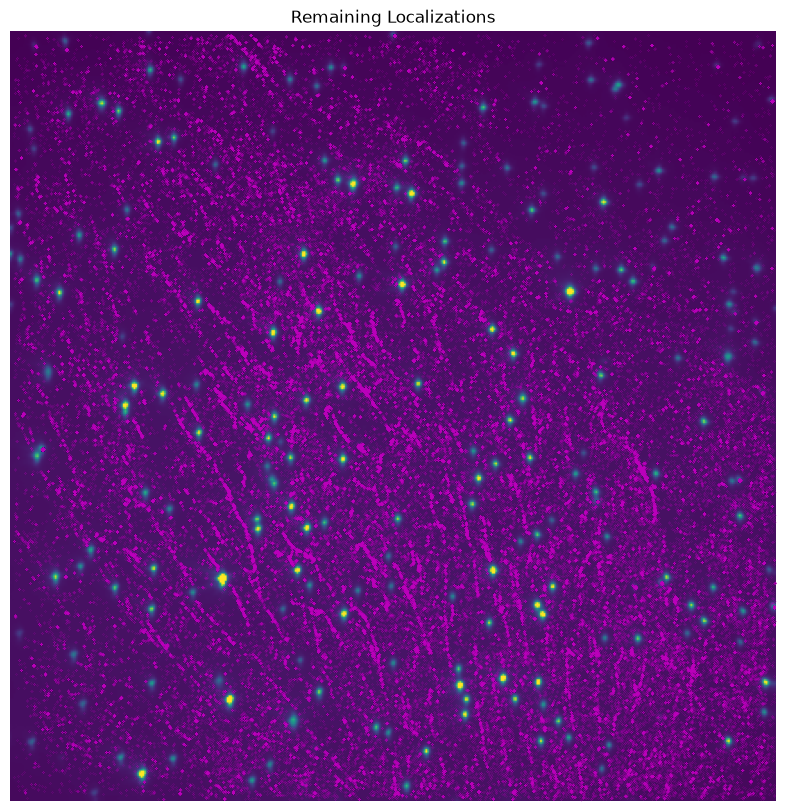

In [6]:
# Plot the removal as a sanity check. If this doesn't look right, don't waste time saving!
fig, axs = plt.subplots()
fig.set_figwidth(10)
fig.set_figheight(10)

axs.imshow(total,aspect='equal',vmin=per01,vmax=per99)
axs.axis('off')
axs.set_title('Remaining Localizations')
axs.plot(ascii[:,2],ascii[:,3],'m.',markersize=0.25)

plt.show()

In [7]:
# Save the results to CSV
toSave = pd.DataFrame(ascii,columns=headers)
toSave.to_csv(saveName,index=False)

In [8]:
tend = datetime.now()
duration = tend-tstart
print(duration)

0:01:06.472721
